# PBC3.py test

In [1]:
from PBC3 import PBC3, PBC3Config
from PBC2_4 import PBC as PBC2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import os
import time

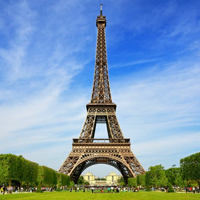

In [2]:
img = Image.open("test_images/eiffel.png")
img.resize((200, 200))

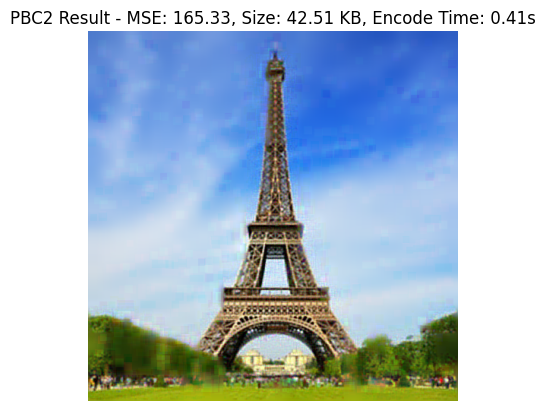

In [3]:
res = PBC2.compress(img)
res.show()

MSE: 648.5081176757812, Compressed Size: 1.47 KB
Encoded and decoded images are identical.


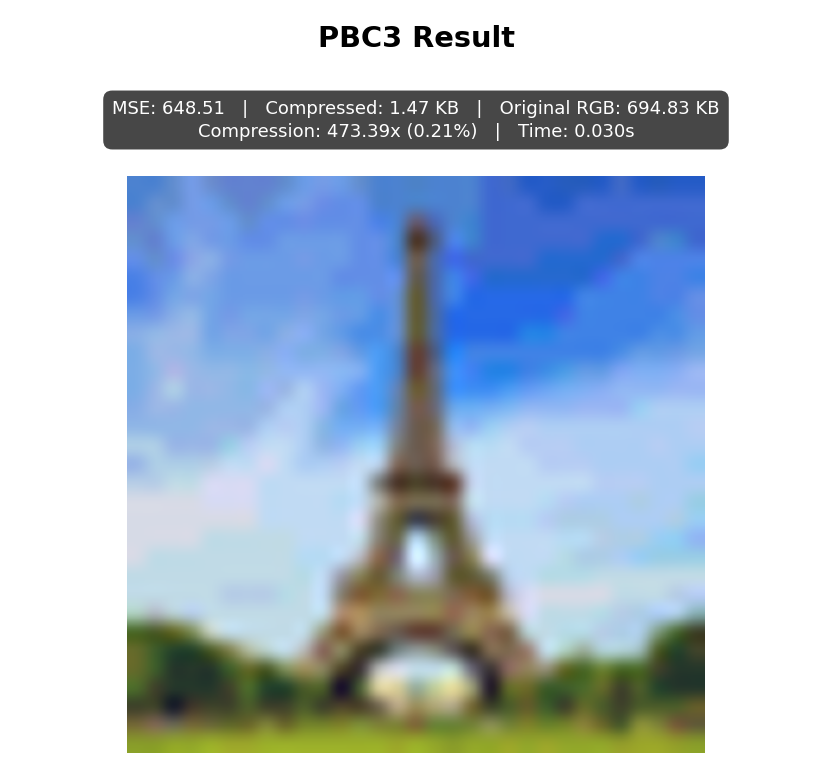

In [11]:
cfg = PBC3Config(
    downsample_cell_size=16,
    mask_size=9,
    palette_max=150,
    palette_bitcount=4,
    patch_count=0,
)

res = PBC3.compress(img, cfg)
decoded = PBC3.decompress(res.data)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.image == decoded.image:
    print("Encoded and decoded images are identical.")
    res.show()
else:
    print("Encoded and decoded images differ.")
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(int) - np.array(decoded.image).astype(int))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()